Secular + offset fit:
  y(t) = y_off + a_sec*cos(ω_sec*t + φ_sec)
  f_sec = ω_sec/(2π) = 0.508694 MHz, a_sec = 4.08093e-05 μm, φ_sec = -4.85965 rad
  Offset y_off = 0.0462069 μm


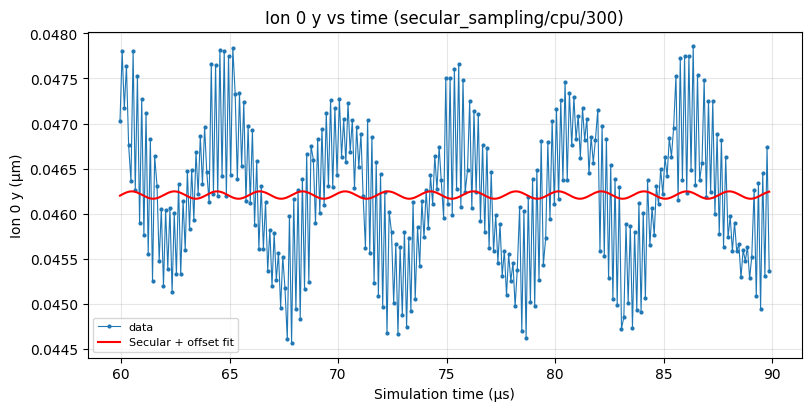

Loaded 300 frames from /home/ylcyyds/ism-space/ism-main/secular_sampling/cpu/300


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# secular_sampling/{device}/{n_ions}/ 与 save_rv_traj_dir / save_rv_status_dir 结构一致
DATA_REL = Path("secular_sampling/cpu/300")

_here = Path.cwd()


def _secular_search_roots():
    """工作目录可能在仓库根、motion_analysis/ 等，向上查找数据根。"""
    roots = []
    seen = set()
    for p in (_here, _here.parent):
        key = p.resolve()
        if key not in seen:
            seen.add(key)
            roots.append(p)
    return roots


def resolve_secular_data_dir() -> Path:
    for root in _secular_search_roots():
        candidate = root / DATA_REL
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"未找到目录 {DATA_REL}（已搜索 {[str(r / DATA_REL) for r in _secular_search_roots()]}）。"
        "请把数据放在仓库根或父级路径下的 secular_sampling/cpu/300/。"
    )


def _npz_sort_key(p: Path):
    stem = p.stem
    if stem.startswith("frame") and stem.replace("frame","").isdigit():
        return (0, int(stem.replace("frame","")))
    if stem.startswith("t") and stem.endswith("us"):
        try:
            return (1, float(stem[1:-2]))
        except ValueError:
            pass
    return (2, stem)


def _frame_index_from_path(p: Path, seq: int) -> int:
    stem = p.stem
    if stem.startswith("frame") and stem.replace("frame","").isdigit():
        return int(stem.replace("frame",""))
    return seq


data_dir = resolve_secular_data_dir()
paths = sorted(data_dir.glob("*.npz"), key=_npz_sort_key)
if not paths:
    raise FileNotFoundError(f"{data_dir.resolve()} 下没有 .npz 文件")

y_um_list: list[float] = []
t_us_list: list[float] = []
frame_indices: list[int] = []
for seq, p in enumerate(paths):
    with np.load(p) as z:
        r = np.asarray(z["r"], dtype=float)
        if r.ndim != 2 or r.shape[0] < 1:
            raise ValueError(f"{p}: r 形状应为 (n_ions, 3)，当前 {r.shape}")
        if "t_us" in z:
            t_us = float(np.asarray(z["t_us"]).ravel()[0])
        else:
            t_us = float("nan")
    y_um_list.append(float(r[0, 1]))
    t_us_list.append(t_us)
    frame_indices.append(_frame_index_from_path(p, seq))

y_um = np.array(y_um_list)
t_us = np.array(t_us_list)
frame_index = np.array(frame_indices, dtype=int)

# --- Secular harmonic + offset only (no micromotion term); t in μs
def y_secular_bias(t_us_arr, y_off, a_sec, omega_sec, phi_sec):
    """
    y(t) = y_off + a_sec * cos(ω_sec * t + φ_sec)
    Positions in μm; t in μs.
    """
    return y_off + a_sec * np.cos(omega_sec * t_us_arr + phi_sec)


use_time_axis = bool(np.all(np.isfinite(t_us)))
x_obs = t_us.astype(float) if use_time_axis else frame_index.astype(float)

ptp = float(np.ptp(y_um))
p0_y_off = float(np.mean(y_um))
p0_a_sec = 0.25 * ptp if ptp > 0 else 0.01
p0_omega_sec = 2 * np.pi * 0.5
p0_phi_sec = 0.0

fit_ok = use_time_axis and len(x_obs) >= 8
popt = None
if fit_ok:
    try:
        popt, _pcov = curve_fit(
            y_secular_bias,
            x_obs,
            y_um,
            p0=[
                p0_y_off,
                p0_a_sec,
                p0_omega_sec,
                p0_phi_sec,
            ],
            maxfev=100_000,
        )
    except RuntimeError:
        fit_ok = False

_title_suffix = str(DATA_REL).replace("\\", "/")
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
plot_kw: dict = {"lw": 0.8, "label": "data"}
if len(y_um) <= 500:
    plot_kw["marker"] = "o"
    plot_kw["ms"] = 2
if use_time_axis:
    ax.plot(t_us, y_um, **plot_kw)
    ax.set_xlabel("Simulation time (μs)")
    ax.set_title(f"Ion 0 y vs time ({_title_suffix})")
else:
    ax.plot(frame_index, y_um, **plot_kw)
    ax.set_xlabel("Frame index")
    ax.set_title(f"Ion 0 y vs frame index ({_title_suffix})")

if fit_ok and popt is not None:
    y_off, a_sec, omega_sec, phi_sec = (float(x) for x in popt)
    x_fine = np.linspace(float(x_obs.min()), float(x_obs.max()), 500)
    y_fit = y_secular_bias(
        x_fine,
        y_off,
        a_sec,
        omega_sec,
        phi_sec,
    )
    ax.plot(
        x_fine,
        y_fit,
        "r-",
        lw=1.5,
        label="Secular + offset fit",
    )
    ax.legend(loc="best", fontsize=8)
    f_sec_mhz = omega_sec / (2 * np.pi)
    print("Secular + offset fit:")
    print("  y(t) = y_off + a_sec*cos(ω_sec*t + φ_sec)")
    print(
        f"  f_sec = ω_sec/(2π) = {f_sec_mhz:.6g} MHz, "
        f"a_sec = {a_sec:.6g} μm, φ_sec = {phi_sec:.6g} rad"
    )
    print(f"  Offset y_off = {y_off:.6g} μm")
else:
    if not use_time_axis:
        print("Fit skipped: need t_us in npz (secular model uses simulation time).")
    else:
        print(
            "Fit skipped: need ≥8 points and a successful least-squares solve "
            "(4 parameters: offset + secular amplitude, frequency, phase)."
        )

ax.set_ylabel("Ion 0 y (μm)")
ax.grid(True, alpha=0.3)
plt.show()

print(f"Loaded {len(paths)} frames from {data_dir.resolve()}")
